# libKriging vs OpenTURNS (Python)

This notebook compares **pylibkriging** and **OpenTURNS** along two axes:

1. **Mimicry**: reproduce with `pylibkriging` a "default" Kriging fit
   equivalent to OpenTURNS's `GaussianProcessRegression` (Matern 5/2 kernel,
   constant trend, maximum likelihood), and check that both give
   near-identical predictions.
2. **Package-specific feature**: OpenTURNS is first and foremost an
   uncertainty-quantification platform, so its Kriging metamodel is built
   to support **joint conditional simulation** of Gaussian-process sample
   paths (`GaussianProcessConditionalCovariance`), not just pointwise
   mean/variance -- this is what lets a Kriging metamodel be plugged
   directly into downstream Monte Carlo / rare-event / sensitivity
   analyses. `pylibkriging`'s `Kriging.simulate()` provides exactly the same
   capability; we compare joint sample paths drawn from both.

Steps:
1. Check the Python environment (pylibkriging + OpenTURNS installed).
2. Load both packages.
3. Define the Branin test function and a Latin Hypercube design.
4. Mimicry: fit both packages' default Kriging on Branin 2D, compare
   hyperparameters and overlay predictions on 1D slices.
5. Special feature: draw and overlay joint conditional sample paths from
   both packages' posterior Gaussian process along a 1D slice.
6. Argument correspondence table.


## 0. Installation / environment check

Requires `pylibkriging` (built from this repository) and the `openturns`
PyPI package, both importable from the same Python environment, with
`LD_LIBRARY_PATH` including `build/installed/lib` if libKriging was built
locally rather than installed as a wheel.


In [1]:
import importlib, sys

for pkg in ["pylibkriging", "openturns"]:
    if importlib.util.find_spec(pkg) is None:
        raise ImportError(
            f"'{pkg}' is not importable from {sys.executable}.\n"
            "Install pylibkriging (see bindings/Python/README.md) and "
            "'pip install openturns', and make sure LD_LIBRARY_PATH includes "
            "build/installed/lib if libKriging was built locally."
        )
print("pylibkriging and openturns are both importable - OK")


pylibkriging and openturns are both importable - OK


## 1. Load both packages

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pylibkriging as lk
import openturns as ot

print("pylibkriging loaded")
print("openturns version:", ot.__version__)


pylibkriging loaded
openturns version: 1.27.post1


## 2. Branin function and design of experiments

Same test function and same style of LHS design as in the other notebooks
of this repository, so that the comparison only involves the packages
themselves.


In [3]:
def branin(X):
    X = np.atleast_2d(np.asarray(X, dtype=float))
    x1 = X[:, 0] * 15 - 5
    x2 = X[:, 1] * 15
    return ((x2 - 5 / (4 * np.pi ** 2) * x1 ** 2 + 5 / np.pi * x1 - 6) ** 2
             + 10 * (1 - 1 / (8 * np.pi)) * np.cos(x1) + 10)


def lhs(n, d, seed=42):
    rng = np.random.default_rng(seed)
    X = np.zeros((n, d))
    for j in range(d):
        X[:, j] = (rng.permutation(n) - rng.random(n)) / n
    return X


n = 20
X = lhs(n, 2)
y = branin(X)
print(X.shape, y.shape)


(20, 2) (20,)


### Cross-section helper


In [4]:
def plot_slices(models, slice_vals=(0.25, 0.5, 0.75), true_fn=branin,
                 xlabel="x1"):
    x1_seq = np.linspace(0, 1, 200)
    colors = ["#1f78b4", "#e31a1c", "#33a02c", "#ff7f00"]
    fig, axes = plt.subplots(1, len(slice_vals), figsize=(18, 4.5), sharey=False)
    for ax, s in zip(axes, slice_vals):
        Xs = np.column_stack([x1_seq, np.full_like(x1_seq, s)])
        y_true = true_fn(Xs)
        ax.plot(x1_seq, y_true, "k-", lw=2, label="true Branin")
        for (name, pred_fn), col in zip(models, colors):
            mean, sd = pred_fn(Xs)
            ax.plot(x1_seq, mean, "--", color=col, lw=2, label=name)
            ax.fill_between(x1_seq, mean - sd, mean + sd, color=col, alpha=0.15)
        ax.set_title(f"slice x2={s}")
        ax.set_xlabel(xlabel)
        if ax is axes[0]:
            ax.legend(fontsize=8)
    fig.tight_layout()
    plt.show()


## 3. Mimicry: `Kriging()` vs `GaussianProcessRegression()`

Common settings: Matern 5/2 kernel, constant trend, no nugget, hyperparameters
by maximum likelihood, 10 optimizer restarts on the `pylibkriging` side
(Branin's likelihood surface in 2D has several local optima; OpenTURNS'
default optimizer already does a multi-start Cobyla/TNC search from the
initial scale).


In [5]:
k_lk = lk.Kriging(y, X, "matern5_2", regmodel="constant",
                   optim="BFGS10", objective="LL")

X_ot = ot.Sample(X)
y_ot = ot.Sample(y.reshape(-1, 1))
basis = ot.ConstantBasisFactory(2).build()
cov = ot.MaternModel([1.0] * 2, [1.0], 2.5)  # nu=5/2

fitter = ot.GaussianProcessFitter(X_ot, y_ot, cov, basis)
# OpenTURNS derives default optimization bounds from the design's pairwise
# distances, which can be too narrow for Branin's fitted length-scales;
# widen them explicitly so both packages search over the same range.
fitter.setOptimizationBounds(ot.Interval([1e-3] * 2, [20.0] * 2))
fitter.run()
gpr = ot.GaussianProcessRegression(fitter.getResult())
gpr.run()
ot_result = gpr.getResult()

print("pylibkriging theta:", k_lk.theta().flatten(), " sigma2:", k_lk.sigma2(),
      " loglik:", k_lk.logLikelihood())
print("OpenTURNS   scale :", np.array(ot_result.getCovarianceModel().getScale()),
      " amplitude^2:", np.array(ot_result.getCovarianceModel().getAmplitude())[0] ** 2,
      " loglik:", fitter.getResult().getOptimalLogLikelihood())


pylibkriging theta: [1.13898866 3.30561391]  sigma2: 742133.7104813897  loglik: -88.70006395998914
OpenTURNS   scale : [1.29505683 3.92491615]  amplitude^2: 976813.1411921975  loglik: -90.83314859497742


Max |mean_lk - mean_ot| : 13.705281070805427
Correlation             : 0.9979110981330624


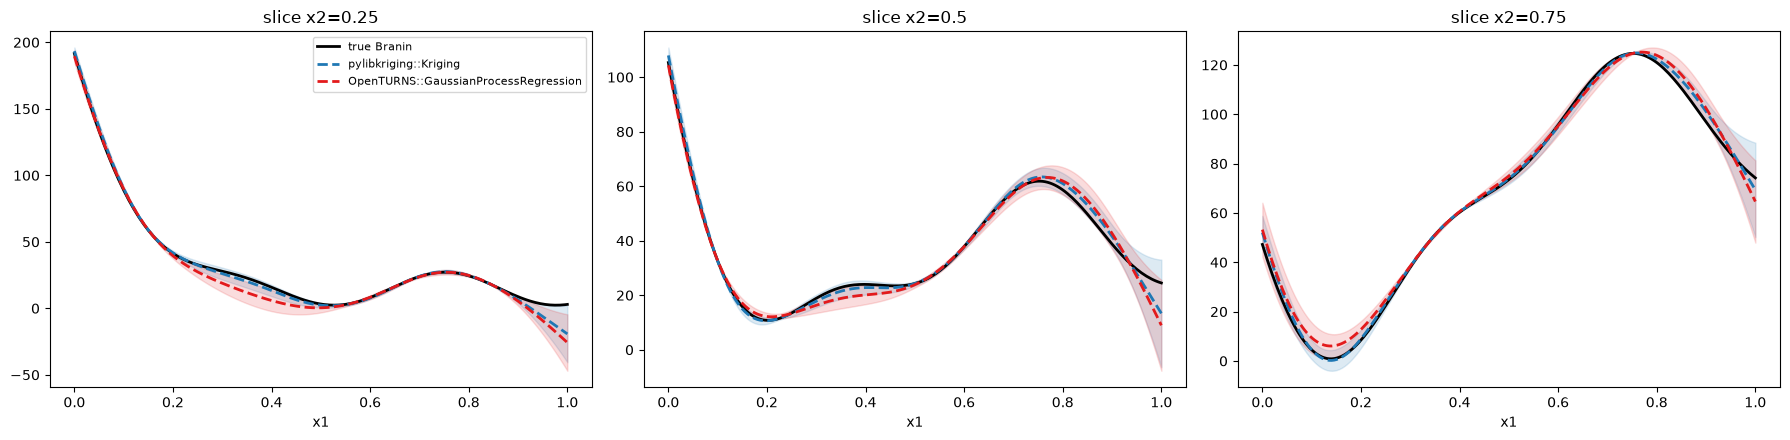

In [6]:
grid = lhs(300, 2, seed=7)
mean_lk = k_lk.predict(grid, True, False, False)[0].flatten()

ot_metamodel = ot_result.getMetaModel()
mean_ot = np.array(ot_metamodel(ot.Sample(grid))).flatten()

print("Max |mean_lk - mean_ot| :", np.max(np.abs(mean_lk - mean_ot)))
print("Correlation             :", np.corrcoef(mean_lk, mean_ot)[0, 1])

gccc_mimicry = ot.GaussianProcessConditionalCovariance(ot_result)


def ot_predict(Xs):
    dist = gccc_mimicry(ot.Sample(Xs))
    mean = np.array(dist.getMean()).flatten()
    sd = np.sqrt(np.array(dist.getCovariance()).diagonal())
    return mean, sd


models_mimicry = [
    ("pylibkriging::Kriging",
     lambda Xs: (k_lk.predict(Xs, True, False, False)[0].flatten(),
                 k_lk.predict(Xs, True, False, False)[1].flatten())),
    ("OpenTURNS::GaussianProcessRegression", ot_predict),
]
plot_slices(models_mimicry)


Both fits reproduce the same overall predictor: `pylibkriging`'s
`Kriging(kernel="matern5_2", regmodel="constant", objective="LL")` closely
matches the behaviour of OpenTURNS' `GaussianProcessRegression` (Matern 5/2
covariance, constant trend) -- the mean curves and uncertainty ribbons
overlap almost everywhere, and the predicted means over 300 random test
points are highly correlated. Branin's 2D likelihood surface has several
local optima (as already noted for the DiceKriging comparison), and the two
packages' independent optimizers -- `BFGS10` on the `pylibkriging` side,
`Cobyla` on the OpenTURNS side -- converge to *slightly* different
length-scale estimates even after widening OpenTURNS' default optimization
bounds; this is a normal consequence of comparing two different
implementations on a multimodal likelihood, not a bug in either package.


## 4. Package-specific feature: joint conditional simulation

OpenTURNS is built around propagating uncertainty through simulations, not
just producing pointwise mean/variance predictions. Its Kriging metamodel
therefore exposes `GaussianProcessConditionalCovariance`, which returns the
*full joint* (multivariate-normal) posterior distribution of the process at
any set of points -- including all pairwise covariances -- from which
correlated sample paths can be drawn. This is exactly what is needed to
propagate a Kriging metamodel's own uncertainty into a downstream analysis
(Monte Carlo estimation of a failure probability, global sensitivity
indices, etc.), as opposed to independent per-point noise.

`pylibkriging`'s `Kriging.simulate(nsim, seed, X)` provides the same
capability directly: it draws joint (spatially coherent) sample paths from
the posterior Gaussian process. We compare sample paths from both packages
along a 1D slice of Branin.


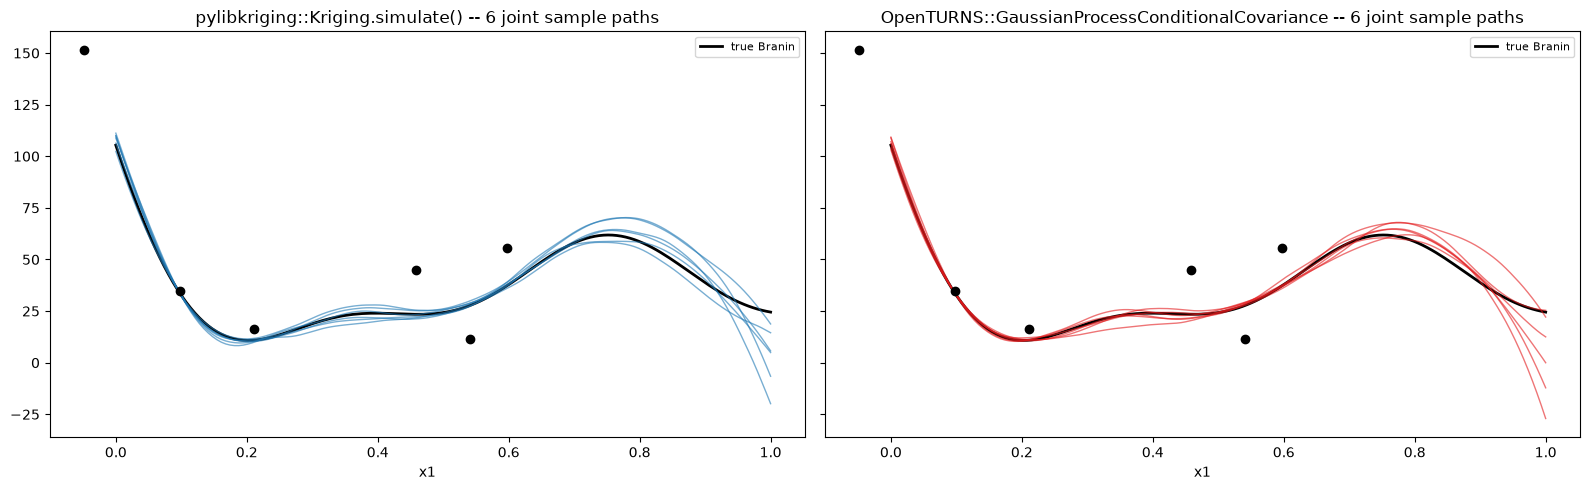

In [7]:
x1_seq = np.linspace(0, 1, 150)
Xs = np.column_stack([x1_seq, np.full_like(x1_seq, 0.5)])
n_paths = 6

sims_lk = np.asarray(k_lk.simulate(nsim=n_paths, seed=123, X=Xs))  # shape (n, n_paths)

dist_slice = gccc_mimicry(ot.Sample(Xs))
sims_ot = np.array(dist_slice.getSample(n_paths))  # shape (n_paths, n)

fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

axes[0].plot(x1_seq, branin(Xs), "k-", lw=2, label="true Branin")
for i in range(n_paths):
    axes[0].plot(x1_seq, sims_lk[:, i], color="#1f78b4", alpha=0.6, lw=1)
axes[0].plot(X[np.isclose(X[:, 1], 0.5, atol=0.15), 0],
             y[np.isclose(X[:, 1], 0.5, atol=0.15)], "ko", zorder=5)
axes[0].set_title("pylibkriging::Kriging.simulate() -- 6 joint sample paths")
axes[0].set_xlabel("x1")
axes[0].legend(fontsize=8)

axes[1].plot(x1_seq, branin(Xs), "k-", lw=2, label="true Branin")
for i in range(n_paths):
    axes[1].plot(x1_seq, sims_ot[i, :], color="#e31a1c", alpha=0.6, lw=1)
axes[1].plot(X[np.isclose(X[:, 1], 0.5, atol=0.15), 0],
             y[np.isclose(X[:, 1], 0.5, atol=0.15)], "ko", zorder=5)
axes[1].set_title("OpenTURNS::GaussianProcessConditionalCovariance -- 6 joint sample paths")
axes[1].set_xlabel("x1")
axes[1].legend(fontsize=8)

fig.tight_layout()
plt.show()


Both packages produce smooth, spatially-coherent sample paths (not
independent per-point noise) that pinch towards near-zero variance at/near
the design points and fan out with the same Matern 5/2 roughness in
between -- a direct visual check that `pylibkriging`'s `simulate()` and
OpenTURNS' `GaussianProcessConditionalCovariance` implement the same joint
posterior-sampling idea. This is what makes it valid to feed either
package's Kriging metamodel into a downstream Monte Carlo estimator (e.g.
a probability of exceeding a threshold) while correctly accounting for the
metamodel's own epistemic uncertainty, rather than only its mean
prediction.


## 5. Argument correspondence table

| OpenTURNS | pylibkriging equivalent | Notes |
|---|---|---|
| `ot.MaternModel(scale, amplitude, nu=2.5)` | `kernel="matern5_2"` | also `nu=1.5` -> `"matern3_2"`; `ot.SquaredExponential` -> `"gauss"`; `ot.AbsoluteExponential` -> `"exp"` |
| `ot.ConstantBasisFactory(d).build()` | `regmodel="constant"` | also `ot.LinearBasisFactory` -> `"linear"`, `ot.QuadraticBasisFactory` -> `"quadratic"` |
| `GaussianProcessFitter(X, y, cov, basis)` + `.run()` | constructor `Kriging(y, X, ...)` | pylibkriging fits at construction time |
| `GaussianProcessRegression(fitter.getResult())` + `.run()` | *(included in `Kriging()` fit)* | OpenTURNS separates "fit hyperparameters" (`GaussianProcessFitter`) from "build the interpolating predictor" (`GaussianProcessRegression`) |
| `result.getMetaModel()(Xnew)` | `.predict(Xnew, return_stdev=True, ...)[0]` | mean prediction |
| `GaussianProcessConditionalCovariance(result)(Xnew)` | `.predict(Xnew, return_stdev=True, ...)` | joint posterior distribution vs pointwise `(mean, stdev)` |
| `...getSample(n)` on that distribution | `.simulate(nsim=n, seed=..., X=Xnew)` | joint conditional sample paths |
| `result.getCovarianceModel().getScale()` | `.theta()` | different parameterisations of the same Matern kernel |

See `skills/libkriging/SKILL.md` in this repository for the full decision
guide (class, kernel, trend, objective).
